In [1]:
using Pkg
Pkg.activate(@__DIR__)
#Pkg.instantiate()
using Revise

using Random
using Statistics
using Adapt
using Functors
using Flux
using Onion
using RandomFeatureMaps
using Zygote

Pkg.develop(path=joinpath(@__DIR__, ".."))
using Flowfusion
const FF = Flowfusion

include(joinpath(@__DIR__, "prob_model.jl"))
include(joinpath(@__DIR__, "helper_funcs.jl"))


  Activating project at `~/dev/Flowfusion.jl/editflow_code`
   Resolving package versions...
  No Changes to `~/dev/Flowfusion.jl/editflow_code/Project.toml`
  No Changes to `~/dev/Flowfusion.jl/editflow_code/Manifest.toml`


plot_len_dist (generic function with 1 method)

In [2]:
import CUDA

# Device helpers
const _gpu_enabled = try
    CUDA.has_cuda()
catch
    false
end

to_dev(x) = _gpu_enabled ? Adapt.adapt(CUDA.CuArray, x) : x
to_cpu(x) = _gpu_enabled ? Adapt.adapt(Array, x) : x
# move x to the same device type as y (Array or CuArray)
to_same_device(x, y) = (_gpu_enabled && (y isa CUDA.CuArray)) ? Adapt.adapt(CUDA.CuArray, x) : Adapt.adapt(Array, x)


to_same_device (generic function with 1 method)

In [3]:
# Load PM target (brings PM and AA20) and minibatch

function make_minibatch(B::Int, P::FF.EditFlow; rng=Random.default_rng())
    K = P.k
    x0s = Vector{FF.DiscreteState}(undef, B)
    x1s = Vector{FF.DiscreteState}(undef, B)
    for b in 1:B
        # x1 from true PM
        seq1 = sample(PM; rng=rng)
        @assert all(1 .<= seq1 .<= K)
        x1s[b] = FF.DiscreteState(K, seq1)
        # x0: uniform tokens with random length in 1:10 (no BOS in x0)
        L0 = rand(rng, 1:10)
        seq0 = rand(rng, 1:K, L0)
        x0s[b] = FF.DiscreteState(K, seq0)
    end
    ts = rand(rng, Float32, B)
    return x0s, x1s, ts
end


make_minibatch (generic function with 1 method)

In [4]:
# Gap-wise helpers

gaps_from_sites_dup(H) = hcat(@view(H[:,1:1,:]), @view(H[:,2:end,:]), @view(H[:,end:end,:]))

function gaps_from_sites_avg(H)
    d, L, B = size(H)
    if L == 1
        middle = @view H[:, 1:0, :]
    else
        @views middle = 0.5f0 .* (H[:, 1:L-1, :] .+ H[:, 2:L, :])
    end
    # safer on GPU than hcat in some view combinations
    return cat(@view(H[:, 1:1, :]), middle, @view(H[:, L:L, :]); dims=2)  # d×(L+1)×B
end


gaps_from_sites_avg (generic function with 1 method)

In [5]:
# Model definition (gap-wise heads)

struct EditFlowModel{L}
    layers::L
end
Flux.@layer EditFlowModel

function EditFlowModel(; d=128, num_heads=8, nlayers=6, rff_dim=128, cond_dim=128, K::Int)
    embedding   = Flux.Embedding(K + 2 => d)
    time_embed  = Flux.Chain(RandomFourierFeatures(1 => rff_dim, 1.0f0), Dense(rff_dim => cond_dim))
    blocks      = [Onion.AdaTransformerBlock(d, cond_dim, num_heads) for _ in 1:nlayers]
    # split heads: ins on gaps, sub/del on sites
    head_ins = Dense(d => K, bias=false)   # gaps (L+1)
    head_sub = Dense(d => K, bias=false)   # sites (L)
    head_del = Dense(d => 1, bias=false)   # sites (L)
    rope        = RoPE(d ÷ num_heads, 4096)
    return EditFlowModel((; embedding, time_embed, blocks, head_ins, head_sub, head_del, rope, K))
end


EditFlowModel

In [ ]:
# Forward (returns logits of shape (2K+1, L+1, B))
function (model::EditFlowModel)(t, Xt_ms)
    m = model.layers
    X = FF.tensor(Xt_ms)
    X = ndims(X) == 1 ? reshape(X, :, 1) : X
    L, B = size(X)

    pmask = Zygote.@ignore FF.getlmask(Xt_ms)
    Xp = X .+ 1                     # embedding is 1-indexed
    H = m.embedding(Xp)             # d×L×B

    t = ndims(t) == 0 ? fill(Float32(t), B) : Float32.(t)
    cond = m.time_embed(reshape(t, 1, B))

    cond  = to_same_device(cond, H)
    pmask = Zygote.@ignore to_same_device(pmask, H)
    rope  = Zygote.@ignore to_same_device(m.rope[1:L], H)

    for blk in m.blocks
        H = blk(H; cond, rope, kpad_mask=pmask)   # d×L×B
    end

    # gap embeddings & heads
    Hg  = gaps_from_sites_avg(H)                  # d×(L+1)×B
    ins = m.head_ins(Hg)                          # K×(L+1)×B
    sub = m.head_sub(H)                           # K×L×B
    del = m.head_del(H)                           # 1×L×B

    # pad sub/del with a zero FIRST column to align sites with gaps (site i ↔ gap i+1)
    @views sub_pad = cat(sub[:, 1:1, :].*0, sub; dims=2)
    @views del_pad = cat(del[:, 1:1, :].*0, del; dims=2)

    return vcat(ins, sub_pad, del_pad)            # (2K+1)×(L+1)×B
end


In [7]:
# Training loop (gap-wise)
function train_editflow!(P::FF.EditFlow,
                         model;
                         epochs::Int=1,
                         steps_per_epoch::Int=100,
                         batch_size::Int=64,
                         lr::Float32=1f-2,
                         seed::Int=42,
                         print_every::Int=25)

    rng = Random.MersenneTwister(seed)
    Random.seed!(seed)

    # device
    model = Functors.fmap(to_dev, model)
    opt_state = Flux.setup(Flux.Adam(lr), model)

    for epoch in 1:epochs
        for step in 1:steps_per_epoch
            # 1) minibatch
            x0s, x1s, ts = make_minibatch(batch_size, P; rng=rng)
            Z0, Z1 = FF.align_and_batch(P, x0s, x1s)
            Zt, Xt = FF.interpolate_Z_elementwise(P, Z0, Z1, ts)

            # prepend BOS to all streams
            bos = P.bos_token
            Zt = vcat(fill(bos, 1, batch_size), Zt)
            Xt = vcat(fill(bos, 1, batch_size), Xt)
            Z1 = vcat(fill(bos, 1, batch_size), Z1)

            # 2) gap-wise masks & multipliers
            transition_mask = FF.transition_mask_from_Xt_gapwise(P, Xt)   # (2K+1, L+1, B)
            edit_multiplier = FF.remaining_edits_gapwise(P, Zt, Z1, Xt)   # (2K+1, L+1, B)
            @assert size(transition_mask) == size(edit_multiplier)
            @assert size(transition_mask, 2) == size(Xt, 1) + 1

            # scheduler
            den = 1f0 .- P.κ.(ts); den = max.(den, 1f-2)
            scheduler_scaling = P.dκ.(ts) ./ den  # length B

            # 3) masked state → device
            lmask = Xt .!= P.padding_token
            cmask = trues(size(lmask))
            Xt_ms = FF.MaskedState(FF.DiscreteState(P.k, Xt), cmask, lmask)

            ts_d    = to_dev(ts)
            Xt_ms_d = to_dev(Xt_ms)
            Tmask_d = to_dev(transition_mask)
            Emult_d = to_dev(edit_multiplier)
            sched_d = to_dev(reshape(Float32.(scheduler_scaling), 1, 1, :))

            # 4) fwd + loss + update
            loss, grad = Flux.withgradient(model) do m
                M = m(ts_d, Xt_ms_d)   # (2K+1, L+1, B)
                # shape sanity
                @assert size(M) == size(Tmask_d) == size(Emult_d)
                FF.edit_loss_gapwise(P, M, Tmask_d, Emult_d, sched_d; eps=1f-8)
            end
            Flux.update!(opt_state, model, grad[1])

            if step % print_every == 0
                @info "train-gapwise" epoch step loss=Float32(loss)
            end
        end
    end

    return Functors.fmap(to_cpu, model)
end


train_editflow! (generic function with 1 method)

In [ ]:
# Init and (optional) train
K = PM.K
println("K: ", K)

P = FF.EditFlow(K; bos_token=0)

model = EditFlowModel(; d=128, num_heads=8, nlayers=4, rff_dim=128, cond_dim=128, K=K)
nothing

K: 20


EditFlowModel(
  Embedding(22 => 128),                 # 2_816 parameters
  Chain(
    RandomFourierFeatures{Float32, Matrix{Float32}}(Float32[-2.4796202 13.478667 … 0.7362796 3.2408502]),
    Dense(128 => 128),                  # 16_512 parameters
  ),
  [
    TransformerBlock(
      Attention(
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        identity,
        identity,
        Onion.var"#32#34"(),
        16,
        16,
        8,
        8,
      ),
      StarGLU(
        Dense(128 => 512; bias=false),  # 65_536 parameters
        Dense(512 => 128; bias=false),  # 65_536 parameters
        Dense(128 => 512; bias=false),  # 65_536 parameters
        NNlib.swish,
      ),
      AdaLN(
        Onion.LayerNorm{Vector{Float32}, Vector{Float32}, Float32}(Float32[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 

In [16]:
# Train; returned model is on CPU
model = train_editflow!(P, model; epochs=10, steps_per_epoch=150, batch_size=256, lr=1f-3)


┌ Info: train-gapwise
│   epoch = 1
│   step = 25
└   loss = 0.04359362f0
┌ Info: train-gapwise
│   epoch = 1
│   step = 50
└   loss = 0.053738564f0
┌ Info: train-gapwise
│   epoch = 1
│   step = 75
└   loss = 0.04167632f0
┌ Info: train-gapwise
│   epoch = 1
│   step = 100
└   loss = 0.03297082f0
┌ Info: train-gapwise
│   epoch = 1
│   step = 125
└   loss = 0.042898107f0
┌ Info: train-gapwise
│   epoch = 1
│   step = 150
└   loss = 0.047004897f0
┌ Info: train-gapwise
│   epoch = 2
│   step = 25
└   loss = 0.031407103f0
┌ Info: train-gapwise
│   epoch = 2
│   step = 50
└   loss = 0.030527484f0
┌ Info: train-gapwise
│   epoch = 2
│   step = 75
└   loss = 0.041389197f0
┌ Info: train-gapwise
│   epoch = 2
│   step = 100
└   loss = 0.051030993f0
┌ Info: train-gapwise
│   epoch = 2
│   step = 125
└   loss = 0.0374101f0
┌ Info: train-gapwise
│   epoch = 2
│   step = 150
└   loss = 0.04102195f0
┌ Info: train-gapwise
│   epoch = 3
│   step = 25
└   loss = 0.026533976f0
┌ Info: train-gapwise
│  

EditFlowModel(
  Embedding(22 => 128),                 # 2_816 parameters
  Chain(
    RandomFourierFeatures{Float32, Matrix{Float32}}(Float32[-2.4796202 13.478667 … 0.7362796 3.2408502]),
    Dense(128 => 128),                  # 16_512 parameters
  ),
  [
    TransformerBlock(
      Attention(
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        Dense(128 => 128; bias=false),  # 16_384 parameters
        identity,
        identity,
        Onion.var"#32#34"(),
        16,
        16,
        8,
        8,
      ),
      StarGLU(
        Dense(128 => 512; bias=false),  # 65_536 parameters
        Dense(512 => 128; bias=false),  # 65_536 parameters
        Dense(128 => 512; bias=false),  # 65_536 parameters
        NNlib.swish,
      ),
      AdaLN(
        Onion.LayerNorm{Vector{Float32}, Vector{Float32}, Float32}(Float32[0.9009282, 0.97761583, 0.95072

In [12]:
function sample_gapwise_strings(P, model; N=20, ts=0.0f0:0.01f0:1.0f0, rng=Random.default_rng())
    out = String[]
    tg = collect(ts)
    for _ in 1:N
        x0s, _, _ = make_minibatch(1, P; rng=rng)   # ta ett x0 per sample
        x0 = x0s[1]
        # lägg till BOS längst fram (träningen hade alltid BOS i pos 1)
        x0_tokens = collect(FF.tensor(x0))
        x0_bos   = FF.DiscreteState(P.k, vcat(P.bos_token, x0_tokens))

        x = FF.rollout_gapwise(P, model, x0_bos, tg; rng=rng)
        seq = collect(FF.tensor(x))
        seq = filter(t -> t != P.bos_token && t != P.padding_token, seq)
        push!(out, String(collect(AA20[seq])))
    end
    return out
end

# Användning
rng = Random.MersenneTwister(42)
ts  = 0.0f0:0.02f0:1.0f0
println("\n=== Gap-wise model samples (20) ===")
for (i, s) in enumerate(sample_gapwise_strings(P, model; N=20, ts=ts, rng=rng))
    println("[", i, "] ", s)
end


=== Gap-wise model samples (20) ===
[1] EVQVNESGKGL
[2] VVFLVQSGGGLVKKPGASVKVQ
[3] VQLVQGGVNLVKPGSAVKKP
[4] QVQVSGAMKRPG
[5] QVQLVKSGPGLVKPG
[6] QVQLRQSGYAEVKKPR
[7] EVELLRSGVLVKPGGD
[8] QVQLLVQSGAEVK
[9] EVHLRESGLGGLPS
[10] QVQRVQQDVKMPGA
[11] EVQLVHSGGG
[12] QLQLQESGGGLVQPGGSR
[13] QVQAQAGEAGVKP
[14] QVQLVQSGANVKRKGSS
[15] EVQLVESGGGLVPGSGLLRL
[16] VLQVQSRGVLVKPNGSVKK
[17] QVTLRRDSTSLVKKP
[18] QVQLVHSAEVK
[19] EVQLVLSGGGILRK
[20] EVQLVESGGGLV


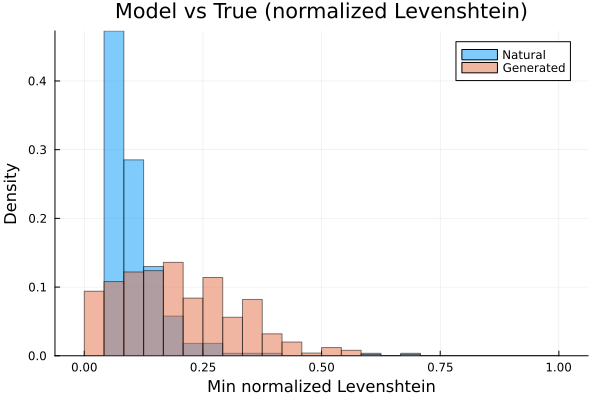

In [17]:
# Sampling and Levenshtein plot
using Random
n = 500

#ts  = 0.0f0:0.01f0:1.0f0
model_strings = sample_gapwise_strings(P, model; N=n, ts=ts, rng=rng)

# Build training strings from PM parents (the data PM was built on)
train_states = [FF.DiscreteState(P.k, sample(PM; rng=Random.MersenneTwister(1000+i))) for i in 1:n]
train_strings = [state_to_PM_string(P, s) for s in train_states]

# Independent validation strings sampled from PM
val_states = [FF.DiscreteState(P.k, sample(PM; rng=Random.MersenneTwister(1000+i+2*n))) for i in 1:n]
val_strings = [state_to_PM_string(P, s) for s in val_states]
val_strings = [s for s in val_strings if !(s in train_strings)]

# Plot normalized Levenshtein vs. training set (distinct val/train)
plt = plot_lev_dist("model_vs_true", val_strings, model_strings, train_strings; title="Model vs True (normalized Levenshtein)")

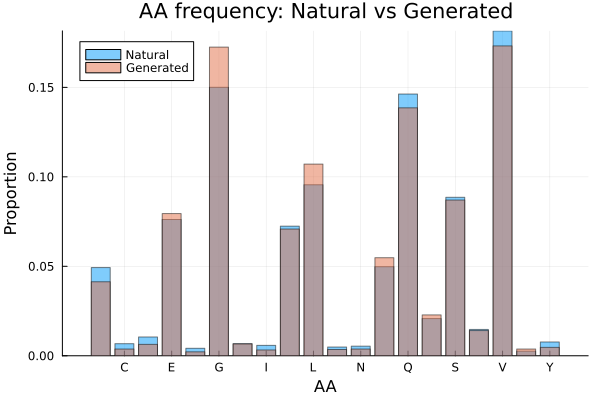

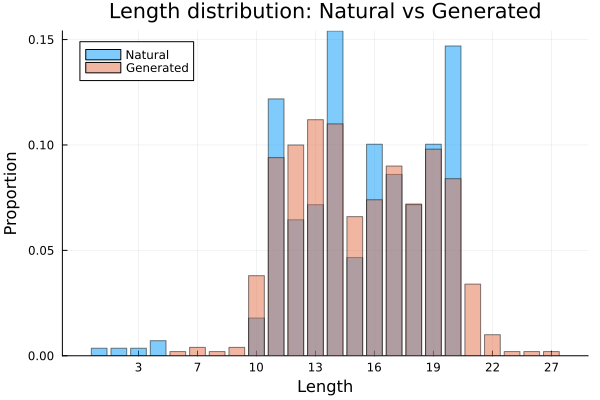

In [18]:
pAA = plot_AA_dist("model_vs_true_AA", val_strings, model_strings; title="AA frequency: Natural vs Generated")
display(pAA)

pLen = plot_len_dist("model_vs_true_len", val_strings, model_strings; title="Length distribution: Natural vs Generated")
display(pLen)
